# Prediction Visualiser

Given a model checkpoint and a video ID, this notebook:
1. Loads features (video, audio, text) for the requested video
2. Runs the model and captures per-FPN-level action scores
3. Draws a three-panel timeline matching Fig. 3 of the paper:
   - **Top**: per-frame action scores aggregated across all pyramid levels
   - **Middle**: weighted onset / offset histograms from the regression output
   - **Bottom**: ground-truth and predicted temporal segments on a shared timeline

## 1 — Configuration

Set the three paths below and run all cells.

In [ ]:
import os

# ── Edit these ────────────────────────────────────────────────────────────────
CONFIG_PATH     = 'configs/experiments/concat_tridet.yaml'
CHECKPOINT_PATH = 'runs/trifuse_tridet/model_best.pth.tar'
#VIDEO_ID        = 'bit_UX20jBz57GJu'
VIDEO_ID        = 'bit_GhbaWPYcrixI' 
#VIDEO_ID        = 'bit_C4MbEUOgiVqN'   # any ID that exists in the annotation file
SUBSET          = 'val'                 # 'train' | 'val' | 'test'
# ─────────────────────────────────────────────────────────────────────────────

# Score threshold for displaying predicted segments
DISPLAY_THRESHOLD = 0.20
# Maximum number of predicted segments to show
MAX_SHOW = 15

## 2 — Imports & path setup

In [2]:
import sys, yaml, json
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Make sure the adapted_actionformer package is importable
_notebook_dir = os.path.dirname(os.path.abspath('.'))
_src_dir = os.path.join(os.path.dirname(os.path.abspath('')), 'adapted_actionformer')
if _src_dir not in sys.path:
    sys.path.insert(0, _src_dir)

from libs.modeling.meta_arch import HatefulContentLocalizer

%matplotlib inline
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 3 — Load config, model, annotations

In [3]:
def load_config(path: str) -> dict:
    """Load YAML and resolve relative feature/annotation paths."""
    config_dir = os.path.dirname(os.path.abspath(path))
    with open(path) as f:
        cfg = yaml.safe_load(f)
    ds = cfg['dataset']
    for key in ('video_feat_dir', 'audio_feat_dir', 'text_feat_dir', 'annotation_file'):
        if key in ds and not os.path.isabs(ds[key]):
            ds[key] = os.path.normpath(os.path.join(config_dir, ds[key]))
    return cfg


cfg = load_config(CONFIG_PATH)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Annotation file: {cfg["dataset"]["annotation_file"]}')

# Load model
model = HatefulContentLocalizer(cfg).to(device)
ckpt  = torch.load(CHECKPOINT_PATH, map_location='cpu')
model.load_state_dict(ckpt.get('state_dict', ckpt))
model.eval()
print(f'Loaded checkpoint: {CHECKPOINT_PATH}')

# Load annotations
with open(cfg['dataset']['annotation_file']) as f:
    annotations = json.load(f)['database']
print(f'Annotation DB size: {len(annotations)} videos')

Device: cuda
Annotation file: c:\Users\Georgiy\Documents\coursework\hateful content localisation\data\hateclipseg\dataset\hateclipseg.json
Loaded checkpoint: runs/trifuse_tridet/model_best.pth.tar
Annotation DB size: 431 videos


## 4 — Load features for a single video

In [4]:
def load_video_features(cfg: dict, video_id: str) -> dict:
    """
    Load and pad/crop the three modality feature files for `video_id`.
    Returns a batch dict ready for the model (batch size = 1).
    """
    ds   = cfg['dataset']
    msl  = ds.get('max_seq_len', 512)

    def _load(feat_dir: str) -> torch.Tensor:
        path = os.path.join(feat_dir, f'{video_id}.pt')
        t    = torch.load(path, map_location='cpu').float()
        if t.ndim == 1:
            t = t.unsqueeze(0)
        return t  # (T, D)

    video_feat = _load(ds['video_feat_dir'])  # (T, 768)
    audio_feat = _load(ds['audio_feat_dir'])  # (T, 1024)
    text_feat  = _load(ds['text_feat_dir'])   # (T, 768)

    T = video_feat.shape[0]

    # Align audio / text length to video
    def _align(feat: torch.Tensor, target_len: int) -> torch.Tensor:
        L = feat.shape[0]
        if L < target_len:
            pad = torch.zeros(target_len - L, feat.shape[1])
            feat = torch.cat([feat, pad], dim=0)
        return feat[:target_len]

    audio_feat = _align(audio_feat, T)
    text_feat  = _align(text_feat,  T)

    # Pad / truncate to max_seq_len
    valid_T = min(T, msl)
    mask    = torch.zeros(msl)
    mask[:valid_T] = 1.0

    def _pad_to(feat: torch.Tensor) -> torch.Tensor:
        t2 = torch.zeros(msl, feat.shape[1])
        t2[:valid_T] = feat[:valid_T]
        return t2

    batch = {
        'video_id'   : [video_id],
        'video_feat' : _pad_to(video_feat).unsqueeze(0),  # (1, T_max, 768)
        'audio_feat' : _pad_to(audio_feat).unsqueeze(0),  # (1, T_max, 1024)
        'text_feat'  : _pad_to(text_feat).unsqueeze(0),   # (1, T_max, 768)
        'mask'       : mask.unsqueeze(0),                  # (1, T_max)
        'duration'   : [annotations[video_id]['duration'] if video_id in annotations else float(T)],
    }
    return batch, valid_T


batch, valid_T = load_video_features(cfg, VIDEO_ID)
duration = batch['duration'][0]
print(f'Video ID : {VIDEO_ID}')
print(f'Duration : {duration:.1f} s  |  Feature frames: {valid_T}')
if VIDEO_ID in annotations:
    ann = annotations[VIDEO_ID]
    print(f'Subset   : {ann["subset"]}')
    for seg in ann.get('annotations', []):
        print(f'  GT segment: {seg["segment"][0]:.1f}s – {seg["segment"][1]:.1f}s  label={seg["label"]}')
else:
    print('(video not found in annotation file — no ground truth available)')

Video ID : bit_C4MbEUOgiVqN
Duration : 182.0 s  |  Feature frames: 182
Subset   : val
  GT segment: 44.6s – 50.6s  label=hate
  GT segment: 50.6s – 59.9s  label=hate
  GT segment: 59.9s – 181.2s  label=hate


## 5 — Run inference and capture per-level scores

In [5]:
@torch.no_grad()
def run_inference_with_internals(model, batch, device):
    """
    Mirrors HatefulContentLocalizer.forward() in eval mode but also returns
    the raw per-FPN-level cls scores and point positions for visualisation.

    Compatible with both the standard ActionFormer head (RegHead) and the
    TriDet Trident-head (TridentRegHead + start_head + end_head).

    Returns
    -------
    results      : list of dicts (same format as model.inference output)
    level_scores : list[np.ndarray]  — per-level sigmoid scores (T_i,)
    level_times  : list[np.ndarray]  — per-level point centres in seconds (T_i,)
    level_offsets: list[np.ndarray]  — per-level decoded (start, end) in seconds (T_i, 2)
    """
    from libs.utils.nms import soft_nms
    from torch.nn import functional as F

    text  = batch['text_feat'].to(device)
    audio = batch['audio_feat'].to(device)
    video = batch['video_feat'].to(device)
    mask  = batch['mask'].to(device)

    # Stage 1: preprocessor
    fused = model.preprocessor(text, audio, video)       # (1, T, fused_dim)
    x     = fused.permute(0, 2, 1)                        # (1, fused_dim, T)
    mask_bcT = mask.unsqueeze(1).bool()                   # (1, 1, T)

    # Stage 2: backbone + neck
    feats, masks         = model.backbone(x, mask_bcT)
    fpn_feats, fpn_masks = model.neck(feats, masks)

    # Grid points: list[(T_i, 4)]  columns: (t_centre, reg_min, reg_max, stride)
    points = model.point_generator(fpn_feats)

    # Stage 3: heads
    raw_cls  = model.cls_head(fpn_feats, fpn_masks)   # list[(1, C, T_i)]
    raw_off  = model.reg_head(fpn_feats, fpn_masks)   # list[(1, 2 or 2*(nb+1), T_i)]
    out_cls  = [c.permute(0, 2, 1) for c in raw_cls]  # list[(1, T_i, C)]
    out_off  = [o.permute(0, 2, 1) for o in raw_off]  # list[(1, T_i, 2 or 2*(nb+1))]
    masks_2d = [m.squeeze(1) for m in fpn_masks]       # list[(1, T_i)]

    # Trident-head boundary logits (only present when head type == 'trident')
    if model.use_trident_head:
        raw_lb = model.start_head(fpn_feats, fpn_masks)  # list[(1, C, T_i)]
        raw_rb = model.end_head(fpn_feats, fpn_masks)    # list[(1, C, T_i)]
    else:
        raw_lb = raw_rb = None

    fps = cfg['dataset'].get('feature_fps', 1.0)

    # Collect per-level scores and decoded segments
    level_scores  = []
    level_times   = []
    level_offsets = []

    segs_all, scores_all = [], []

    for lvl, (cls_i, off_i, pts_i, msk_i) in enumerate(
        zip(out_cls, out_off, points, masks_2d)
    ):
        # scores: (T_i,) — masked
        score = (cls_i[0].sigmoid() * msk_i[0].unsqueeze(-1)).squeeze(-1).cpu()

        pts_cpu = pts_i.cpu()  # (T_i, 4)
        t_centres = pts_cpu[:, 0].numpy() / fps  # in seconds

        # ── Offset decoding: standard vs Trident-head ────────────────────────
        if model.use_trident_head:
            nb = model.num_bins
            sb = raw_lb[lvl][0]  # (C, T_i) — start boundary logits
            eb = raw_rb[lvl][0]  # (C, T_i) — end   boundary logits

            # Build sliding-window boundary neighbour views (C, T_i, nb+1)
            x_pad    = F.pad(sb, (nb, 0), mode='constant', value=0).unsqueeze(-1)
            sz       = list(x_pad.size()); sz[-1] = nb + 1; sz[-2] -= nb
            st       = list(x_pad.stride()); st[-2] = st[-1]
            start_nb = x_pad.as_strided(size=sz, stride=st)

            x_pad   = F.pad(eb, (0, nb), mode='constant', value=0).unsqueeze(-1)
            end_nb  = x_pad.as_strided(size=sz, stride=st)

            # decode_offset returns (C, T_i, 2); select class 0 for binary
            off_decoded = model.decode_offset(off_i[0], start_nb, end_nb)
            off_cpu     = off_decoded[0].cpu()  # (T_i, 2)
        else:
            off_cpu = off_i[0].cpu()  # (T_i, 2)

        seg_l   = (pts_cpu[:, 0] - off_cpu[:, 0] * pts_cpu[:, 3]).numpy() / fps
        seg_r   = (pts_cpu[:, 0] + off_cpu[:, 1] * pts_cpu[:, 3]).numpy() / fps
        decoded = np.stack([seg_l, seg_r], axis=1)  # (T_i, 2)

        score_np = score.numpy()
        level_scores.append(score_np)
        level_times.append(t_centres)
        level_offsets.append(decoded)

        # Collect all detections above threshold for NMS
        keep = score > model.score_threshold
        if keep.sum() > 0:
            segs_k = torch.tensor(decoded[keep.numpy()])
            segs_all.append(segs_k * fps)  # NMS expects feature-frame units
            scores_all.append(score[keep])

    # Apply Soft-NMS
    if segs_all:
        segs_cat   = torch.cat(segs_all, dim=0)
        scores_cat = torch.cat(scores_all, dim=0)
        segs_nms, scores_nms = soft_nms(
            segs_cat, scores_cat,
            sigma=model.nms_sigma,
            min_score=model.score_threshold,
            max_num=model.max_detections,
        )
        segs_sec = (segs_nms / fps).clamp(min=0.0, max=float(batch['duration'][0]))
    else:
        segs_sec   = torch.zeros((0, 2))
        scores_nms = torch.zeros((0,))

    results = [{
        'video_id': batch['video_id'][0],
        'segments': segs_sec,
        'scores'  : scores_nms,
        'labels'  : torch.zeros(segs_sec.shape[0], dtype=torch.long),
    }]

    return results, level_scores, level_times, level_offsets


results, level_scores, level_times, level_offsets = run_inference_with_internals(
    model, batch, device
)
res = results[0]
print(f'Predicted segments after NMS: {res["segments"].shape[0]}')
for i, (s, e, sc) in enumerate(zip(
    res['segments'][:, 0], res['segments'][:, 1], res['scores']
)):
    print(f'  [{i}]  {s:.2f}s – {e:.2f}s   score={sc:.4f}')

Predicted segments after NMS: 86
  [0]  38.30s – 47.93s   score=0.6119
  [1]  1.55s – 14.14s   score=0.5147
  [2]  60.26s – 150.03s   score=0.4237
  [3]  170.42s – 180.69s   score=0.3900
  [4]  20.64s – 26.05s   score=0.3386
  [5]  44.21s – 49.56s   score=0.3331
  [6]  130.16s – 172.64s   score=0.3246
  [7]  15.98s – 21.51s   score=0.1676
  [8]  57.92s – 67.94s   score=0.1502
  [9]  141.64s – 151.53s   score=0.1445
  [10]  24.92s – 30.29s   score=0.1426
  [11]  100.14s – 111.84s   score=0.1294
  [12]  66.83s – 90.06s   score=0.1059
  [13]  178.91s – 182.00s   score=0.1049
  [14]  7.00s – 15.86s   score=0.1024
  [15]  159.95s – 170.41s   score=0.1017
  [16]  28.08s – 44.87s   score=0.1002
  [17]  52.05s – 58.23s   score=0.0935
  [18]  0.00s – 7.70s   score=0.0917
  [19]  121.01s – 134.25s   score=0.0825
  [20]  109.21s – 120.57s   score=0.0706
  [21]  152.49s – 159.36s   score=0.0577
  [22]  87.29s – 100.63s   score=0.0507
  [23]  76.78s – 82.92s   score=0.0489
  [24]  23.47s – 27.92s  

## 6 — Visualise

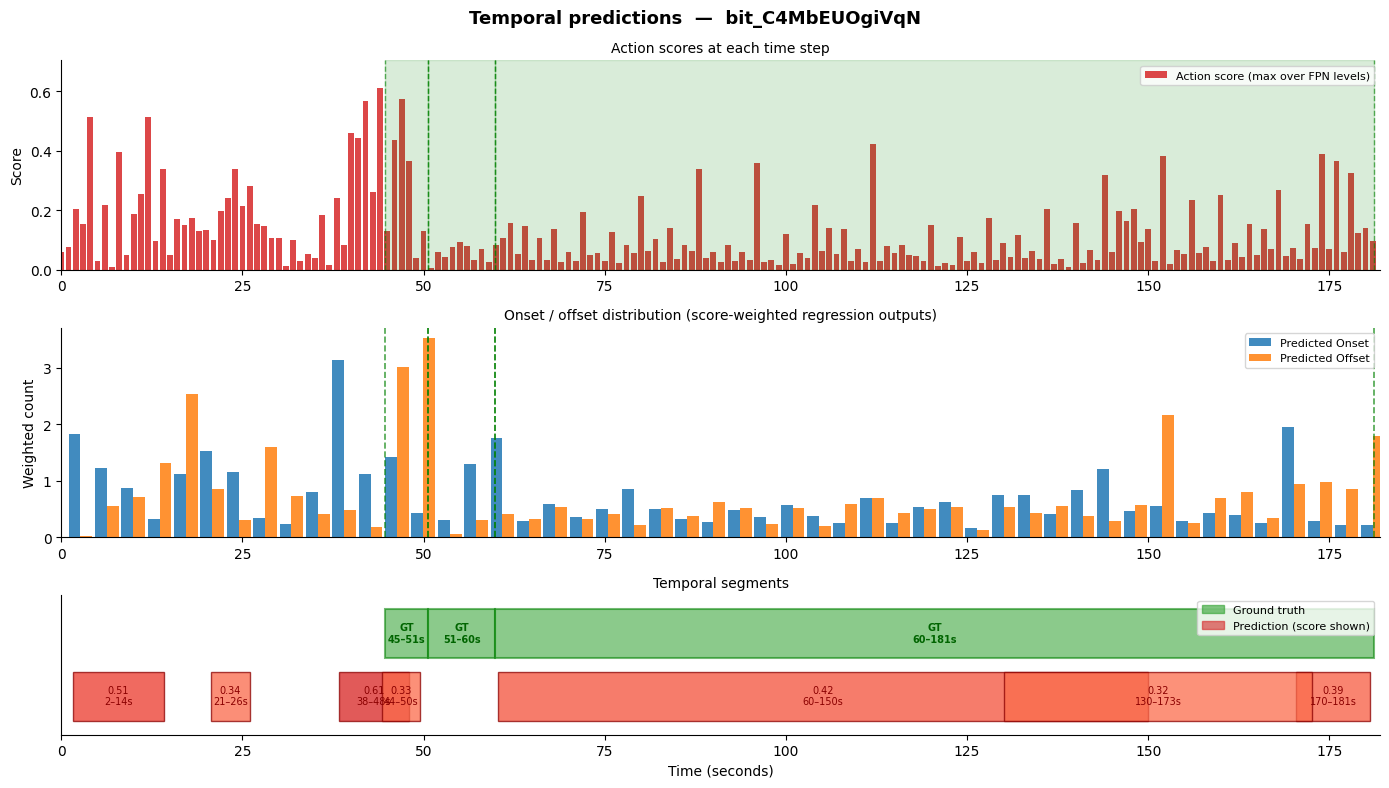

In [6]:
def make_dense_score_curve(level_scores, level_times, duration, fps=1.0):
    """
    Build a dense per-second action-score array by taking the max across all FPN
    levels at each second.  Resolution = 1 second (matching feature_fps).
    """
    n_bins = int(np.ceil(duration)) + 1
    dense  = np.zeros(n_bins)
    for scores, times in zip(level_scores, level_times):
        for t, s in zip(times, scores):
            idx = int(round(t))
            if 0 <= idx < n_bins:
                dense[idx] = max(dense[idx], float(s))
    return np.arange(n_bins), dense


def make_boundary_histograms(level_scores, level_offsets, level_times, duration, n_bins=50):
    """
    Weighted onset / offset histograms as in Fig. 3 bottom panel.
    Each detected point contributes its decoded start/end weighted by its score.
    """
    bin_edges = np.linspace(0, duration, n_bins + 1)
    onset_hist  = np.zeros(n_bins)
    offset_hist = np.zeros(n_bins)

    for scores, offsets, times in zip(level_scores, level_offsets, level_times):
        for i, (s, (t_start, t_end)) in enumerate(zip(scores, offsets)):
            if s < 1e-4:
                continue
            idx_s = np.searchsorted(bin_edges, t_start, side='right') - 1
            idx_e = np.searchsorted(bin_edges, t_end,   side='right') - 1
            if 0 <= idx_s < n_bins:
                onset_hist[idx_s]  += float(s)
            if 0 <= idx_e < n_bins:
                offset_hist[idx_e] += float(s)

    bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    return bin_centres, onset_hist, offset_hist


def visualise(video_id, res, level_scores, level_times, level_offsets,
              annotations, duration, display_threshold=0.10, max_show=10):

    fps     = cfg['dataset'].get('feature_fps', 1.0)
    t_axis, dense = make_dense_score_curve(level_scores, level_times, duration, fps)
    bin_c, onset_h, offset_h = make_boundary_histograms(
        level_scores, level_offsets, level_times, duration
    )

    # Ground truth
    gt_segs = []
    if video_id in annotations:
        for ann in annotations[video_id].get('annotations', []):
            gt_segs.append(ann['segment'])

    # Predicted segments above display threshold, sorted by score
    pred_segs   = res['segments'].numpy()
    pred_scores = res['scores'].numpy()
    keep_mask   = pred_scores >= display_threshold
    pred_segs   = pred_segs[keep_mask][:max_show]
    pred_scores = pred_scores[keep_mask][:max_show]

    # ── Figure layout ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        3, 1,
        figsize=(14, 8),
        gridspec_kw={'height_ratios': [3, 3, 2]},
        sharex=False,
    )
    fig.suptitle(f'Temporal predictions  —  {video_id}', fontsize=13, fontweight='bold')

    # ── Panel 1: per-frame action scores ──────────────────────────────────────
    ax1 = axes[0]
    ax1.bar(t_axis, dense, width=0.8, color='#d62728', alpha=0.85, label='Action score (max over FPN levels)')
    ax1.set_xlim(0, duration)
    ax1.set_ylim(0, max(dense.max() * 1.15, 0.05))
    ax1.set_ylabel('Score', fontsize=10)
    ax1.set_title('Action scores at each time step', fontsize=10)
    ax1.legend(fontsize=8, loc='upper right')

    # shade GT segments
    for s, e in gt_segs:
        ax1.axvspan(s, e, alpha=0.15, color='green', label='_')

    # ── Panel 2: weighted onset / offset histograms ───────────────────────────
    ax2 = axes[1]
    width = bin_c[1] - bin_c[0] if len(bin_c) > 1 else 1.0
    ax2.bar(bin_c, onset_h,  width=width * 0.45, align='center',
            color='#1f77b4', alpha=0.85, label='Predicted Onset')
    ax2.bar(bin_c + width * 0.45, offset_h, width=width * 0.45, align='center',
            color='#ff7f0e', alpha=0.85, label='Predicted Offset')
    ax2.set_xlim(0, duration)
    ax2.set_ylabel('Weighted count', fontsize=10)
    ax2.set_title('Onset / offset distribution (score-weighted regression outputs)', fontsize=10)
    ax2.legend(fontsize=8, loc='upper right')

    # vertical markers for GT boundaries
    for s, e in gt_segs:
        ax2.axvline(s, color='green', linewidth=1.2, linestyle='--', alpha=0.7)
        ax2.axvline(e, color='green', linewidth=1.2, linestyle='--', alpha=0.7)

    # ── Panel 3: timeline with GT and predictions ─────────────────────────────
    ax3 = axes[2]
    ax3.set_xlim(0, duration)
    ax3.set_ylim(0, 1)
    ax3.set_yticks([])
    ax3.set_xlabel('Time (seconds)', fontsize=10)
    ax3.set_title('Temporal segments', fontsize=10)

    # Ground truth: green rectangles
    for s, e in gt_segs:
        ax3.add_patch(mpatches.FancyArrow(
            0, 0, 0, 0, width=0  # invisible placeholder for legend
        ))
        ax3.add_patch(mpatches.Rectangle(
            (s, 0.55), e - s, 0.35,
            linewidth=1.5, edgecolor='green', facecolor='#2ca02c', alpha=0.55,
        ))
        ax3.text((s + e) / 2, 0.73, f'GT\n{s:.0f}–{e:.0f}s',
                 ha='center', va='center', fontsize=7, color='darkgreen', fontweight='bold')

    # Predictions: red/orange rectangles, opacity ∝ score
    norm  = Normalize(vmin=display_threshold, vmax=1.0)
    cmap  = plt.cm.Reds
    for s, e, sc in zip(pred_segs[:, 0], pred_segs[:, 1], pred_scores):
        colour = cmap(0.4 + 0.6 * norm(sc))
        ax3.add_patch(mpatches.Rectangle(
            (s, 0.10), e - s, 0.35,
            linewidth=1.0, edgecolor='darkred', facecolor=colour, alpha=0.75,
        ))
        ax3.text((s + e) / 2, 0.28, f'{sc:.2f}\n{s:.0f}–{e:.0f}s',
                 ha='center', va='center', fontsize=7, color='darkred')

    # Legend
    legend_patches = [
        mpatches.Patch(color='#2ca02c', alpha=0.6, label='Ground truth'),
        mpatches.Patch(color='#d62728', alpha=0.6, label='Prediction (score shown)'),
    ]
    ax3.legend(handles=legend_patches, fontsize=8, loc='upper right')

    # Shared vertical lines for GT boundaries on panels 1 & 2
    for s, e in gt_segs:
        for ax in (ax1,):
            ax.axvline(s, color='green', linewidth=1.0, linestyle='--', alpha=0.6)
            ax.axvline(e, color='green', linewidth=1.0, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


visualise(
    VIDEO_ID, res, level_scores, level_times, level_offsets,
    annotations, duration,
    display_threshold=DISPLAY_THRESHOLD,
    max_show=MAX_SHOW,
)

## 7 — Per-FPN-level score breakdown (optional)

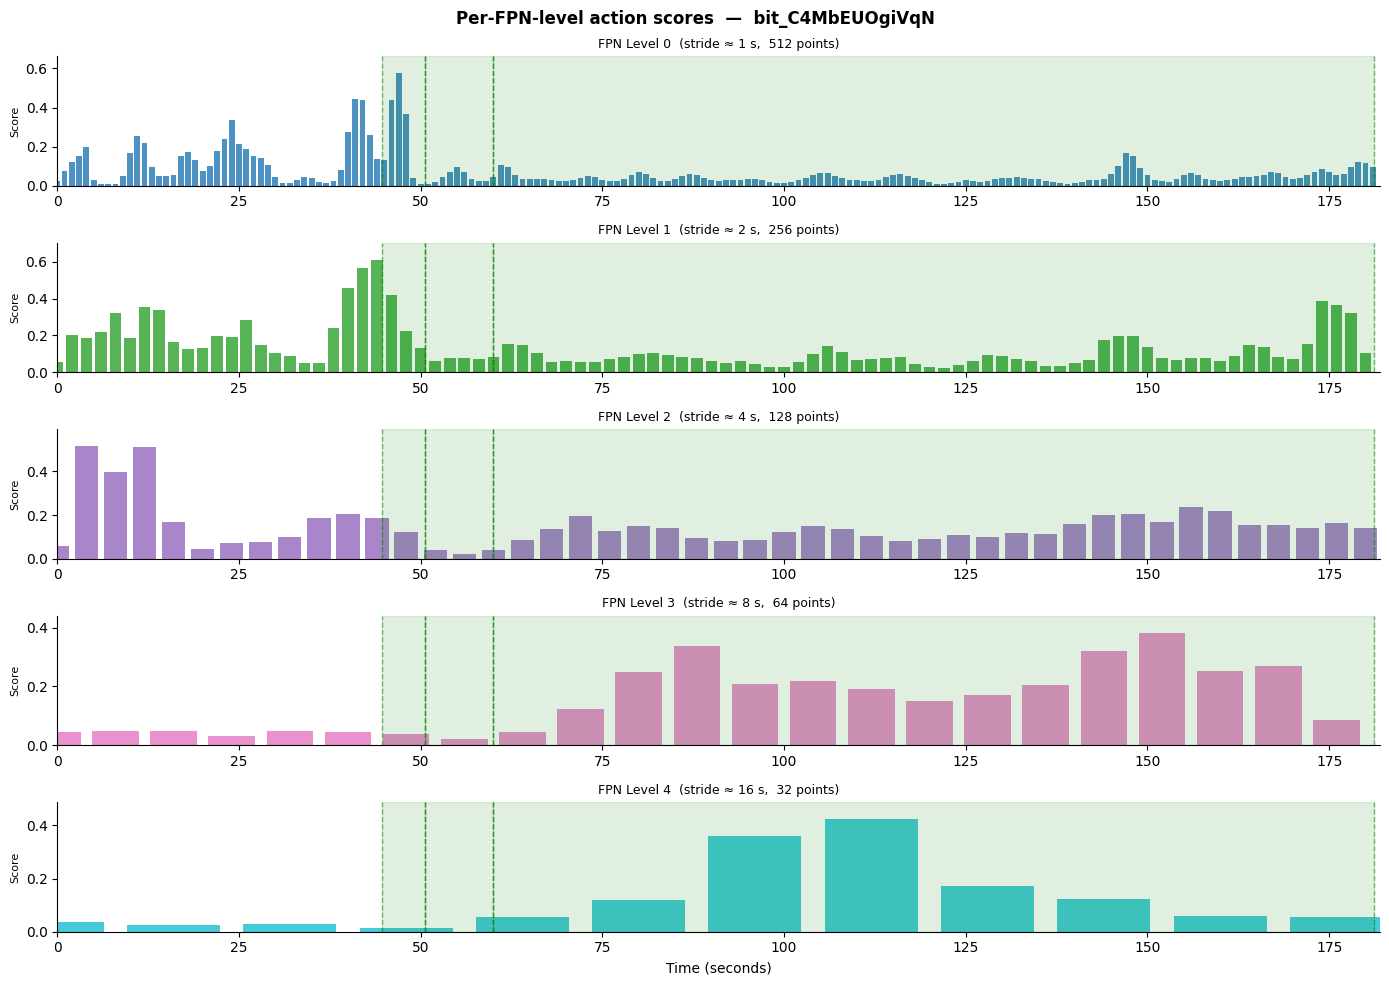

In [7]:
n_levels = len(level_scores)
fig, axes = plt.subplots(n_levels, 1, figsize=(14, 2 * n_levels), sharex=False)
if n_levels == 1:
    axes = [axes]

gt_segs = []
if VIDEO_ID in annotations:
    for ann in annotations[VIDEO_ID].get('annotations', []):
        gt_segs.append(ann['segment'])

colours = plt.cm.tab10(np.linspace(0, 0.9, n_levels))

for lvl, (ax, scores, times) in enumerate(zip(axes, level_scores, level_times)):
    stride = int(round(times[1] - times[0])) if len(times) > 1 else 1
    ax.bar(times, scores, width=stride * 0.8, color=colours[lvl], alpha=0.8)
    for s, e in gt_segs:
        ax.axvspan(s, e, alpha=0.12, color='green')
        ax.axvline(s, color='green', linewidth=1.0, linestyle='--', alpha=0.5)
        ax.axvline(e, color='green', linewidth=1.0, linestyle='--', alpha=0.5)
    ax.set_xlim(0, duration)
    ax.set_ylim(0, max(scores.max() * 1.15, 0.05))
    ax.set_ylabel('Score', fontsize=8)
    ax.set_title(f'FPN Level {lvl}  (stride ≈ {stride} s,  {len(times)} points)', fontsize=9)

axes[-1].set_xlabel('Time (seconds)', fontsize=10)
fig.suptitle(f'Per-FPN-level action scores  —  {VIDEO_ID}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()